In [16]:
!pip install imbalanced-learn



   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [2]:
import numpy as np
import pandas as pd
%matplotlib Inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, confusion_matrix)

from imblearn.over_sampling import SMOTE
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv("Creditcard_data.csv")

In [4]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,575,-0.572263,0.731748,1.541254,0.150506,1.108974,0.372152,1.084879,-0.146329,-0.274447,...,-0.143508,-0.107582,-0.418263,-0.731029,0.877525,-0.364150,-0.177509,-0.256545,26.72,0
768,579,-1.296845,-0.511605,2.404726,-0.310762,-0.319551,-0.542842,-0.173310,0.260423,-1.202688,...,-0.071270,-0.161175,0.088496,0.285390,0.281069,-0.370130,0.043410,0.092318,80.00,0
769,579,1.214170,0.210481,0.484651,0.479768,-0.261955,-0.527039,0.021782,-0.106888,-0.037631,...,-0.224292,-0.594609,0.159877,0.091873,0.140964,0.227406,-0.017389,0.016030,5.98,0
770,580,1.267030,-0.071114,0.037680,0.512683,0.242392,0.705212,-0.226582,0.109483,0.657565,...,-0.164468,-0.177225,-0.222918,-1.245505,0.678360,0.525059,0.002920,-0.003333,12.36,0


In [5]:
df.shape

(772, 31)

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df["Hour"]=(df["Time"]%86400)//3600
df=df.drop(columns=["Time"])

In [6]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,-0.572263,0.731748,1.541254,0.150506,1.108974,0.372152,1.084879,-0.146329,-0.274447,-0.663670,...,-0.107582,-0.418263,-0.731029,0.877525,-0.364150,-0.177509,-0.256545,26.72,0,0
768,-1.296845,-0.511605,2.404726,-0.310762,-0.319551,-0.542842,-0.173310,0.260423,-1.202688,0.050584,...,-0.161175,0.088496,0.285390,0.281069,-0.370130,0.043410,0.092318,80.00,0,0
769,1.214170,0.210481,0.484651,0.479768,-0.261955,-0.527039,0.021782,-0.106888,-0.037631,-0.144073,...,-0.594609,0.159877,0.091873,0.140964,0.227406,-0.017389,0.016030,5.98,0,0
770,1.267030,-0.071114,0.037680,0.512683,0.242392,0.705212,-0.226582,0.109483,0.657565,-0.276918,...,-0.177225,-0.222918,-1.245505,0.678360,0.525059,0.002920,-0.003333,12.36,0,0


In [26]:
 fraud_count =df["Class"].sum()

In [27]:
fraud_pct = df["Class"].mean() * 100

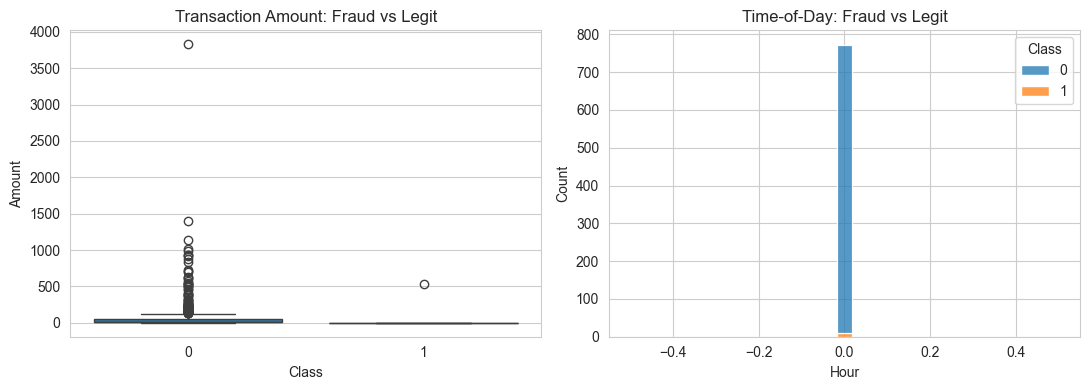

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0])
axes[0].set_title("Transaction Amount: Fraud vs Legit")
sns.histplot(data=df, x="Hour", hue="Class", bins=29, multiple="stack", ax=axes[1])
axes[1].set_title("Time-of-Day: Fraud vs Legit")
plt.tight_layout()
plt.savefig("01_eda.pdf")
plt.show()

In [8]:
feature_cols = [c for c in df.columns if c not in ("Class", "Time")]
X = df[feature_cols]
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Test set fraud cases: {y_test.sum()} out of {len(y_test)} rows.")

smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.sum() - 1))
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE, training class balance: {y_train_res.value_counts().to_dict()}")

Test set fraud cases: 2 out of 155 rows.

After SMOTE, training class balance: {0: 610, 1: 610}


In [10]:
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_res, y_train_res)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

In [11]:
lr_precision = precision_score(y_test, lr_preds, zero_division=0)
lr_recall = recall_score(y_test, lr_preds, zero_division=0)
lr_f1 = f1_score(y_test, lr_preds, zero_division=0)
lr_auc = roc_auc_score(y_test, lr_probs) if y_test.nunique() > 1 else float("nan")
print("\nLogisticRegression")
print(f"Precision: {lr_precision:.3f}  Recall: {lr_recall:.3f}  "
      f"F1: {lr_f1:.3f}  AUC-ROC: {lr_auc:.3f}")
print("Confusion matrix:\n", confusion_matrix(y_test, lr_preds))


LogisticRegression
Precision: 0.083  Recall: 0.500  F1: 0.143  AUC-ROC: 0.565
Confusion matrix:
 [[142  11]
 [  1   1]]


In [12]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_precision = precision_score(y_test, rf_preds, zero_division=0)
rf_recall = recall_score(y_test, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_probs) if y_test.nunique() > 1 else float("nan")

print("\n=== RandomForest ===")
print(f"Precision: {rf_precision:.3f}  Recall: {rf_recall:.3f}  "
      f"F1: {rf_f1:.3f}  AUC-ROC: {rf_auc:.3f}")
print("Confusion matrix:\n", confusion_matrix(y_test, rf_preds))


=== RandomForest ===
Precision: 1.000  Recall: 0.500  F1: 0.667  AUC-ROC: 0.556
Confusion matrix:
 [[153   0]
 [  1   1]]


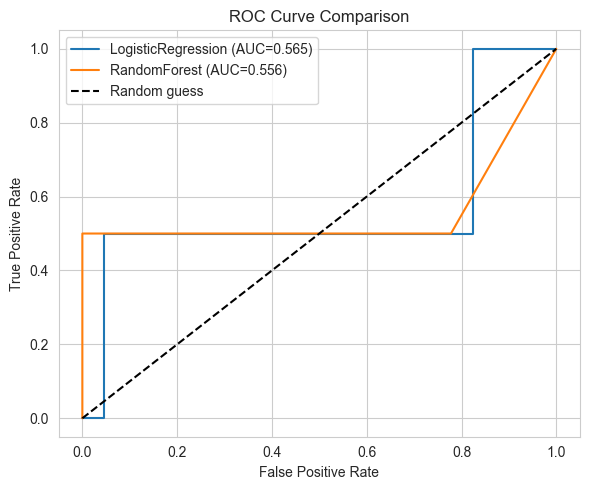

In [22]:
plt.figure(figsize=(6, 5))

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
plt.plot(lr_fpr, lr_tpr, label=f"LogisticRegression (AUC={lr_auc:.3f})")

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(rf_fpr, rf_tpr, label=f"RandomForest (AUC={rf_auc:.3f})")

plt.plot( [0,1],[0,1],"k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("02_roc_curve.pdf")
plt.show()

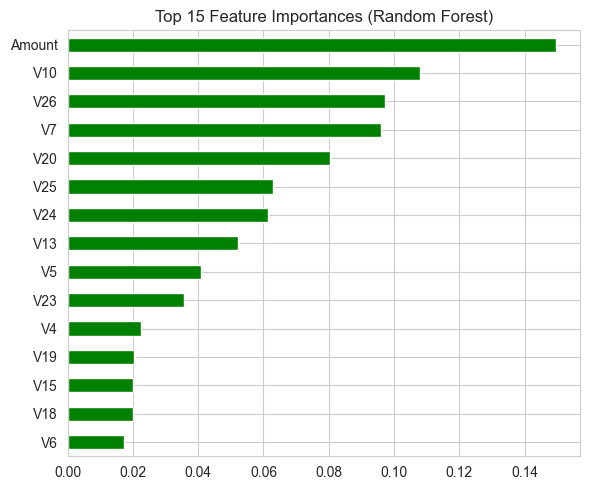


Top feature importances:
 Amount    0.149472
V10       0.107896
V26       0.097157
V7        0.096001
V20       0.080378
V25       0.063022
V24       0.061277
V13       0.052194
V5        0.041001
V23       0.035754
V4        0.022490
V19       0.020367
V15       0.020004
V18       0.019888
V6        0.017300
dtype: float64
Fraud detection complete.


In [23]:

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(6, 5))
importances.plot(kind="barh", color="green")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("03_feature_importance.pdf")
plt.show()
print("\nTop feature importances:\n", importances)
print("Fraud detection complete.")